# Treinamento com interface de alto nível

## Importação das bibliotecas

In [1]:
# http://pytorch.org/
from os.path import exists

import torch

In [2]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

# Baixando Dataset

In [3]:
#!/bin/bash
!curl -L -o /content/microsoft-catsvsdogs-dataset.zip https://www.kaggle.com/api/v1/datasets/download/shaunthesheep/microsoft-catsvsdogs-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  787M  100  787M    0     0  28.1M      0  0:00:27  0:00:27 --:--:-- 29.3M


In [4]:
!unzip -q -o /content/microsoft-catsvsdogs-dataset.zip -d /content/microsoft-catsvsdogs-dataset

In [5]:
catsdogs_folder = "/content/microsoft-catsvsdogs-dataset/PetImages"

In [6]:
class CatsDogsDataset(datasets.ImageFolder):
  def __init__(self, root, transform=None):
    super(CatsDogsDataset, self).__init__(root, transform)

  def __getitem__(self, index):
    try:
      return super(CatsDogsDataset, self).__getitem__(index)
    except:
      print(f"Erro ao carregar imagem. Pulando Imagem {index}")
      return None

In [7]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.0,), (1.0,))
    ])

In [8]:
dataset = CatsDogsDataset(catsdogs_folder, transform=transform)

In [9]:
print(dataset)

Dataset CatsDogsDataset
    Number of datapoints: 25000
    Root location: /content/microsoft-catsvsdogs-dataset/PetImages
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               Grayscale(num_output_channels=1)
               ToTensor()
               Normalize(mean=(0.0,), std=(1.0,))
           )


In [10]:
dataset[1]

(tensor([[[0.1608, 0.1647, 0.1647,  ..., 0.6039, 0.7529, 0.7686],
          [0.1686, 0.1686, 0.1647,  ..., 0.6118, 0.7490, 0.7608],
          [0.1608, 0.1490, 0.1451,  ..., 0.5961, 0.7176, 0.7686],
          ...,
          [0.0863, 0.0745, 0.0745,  ..., 0.1922, 0.2235, 0.1373],
          [0.1059, 0.0863, 0.0824,  ..., 0.1686, 0.1373, 0.1373],
          [0.1137, 0.0902, 0.0902,  ..., 0.1922, 0.1373, 0.1451]]]),
 0)

In [11]:
train_dataset, test_dataset = random_split(dataset, [0.7, 0.3])

In [12]:
len(train_dataset)

17500

In [13]:
len(test_dataset)

7500

## Criação da rede

In [14]:
net_input = 128*128
net_output = 2 # cat e dog

In [15]:
class Net(nn.Module):
    def __init__(self, net_input, net_output):
        super(Net, self).__init__()
        self.net_input = net_input
        self.fc = nn.Sequential(
            nn.Linear(net_input, 2048),
            nn.ReLU(),
            nn.Linear(2048, 4096),
            nn.ReLU(),
            nn.Linear(4096, 8192),
            nn.ReLU(),
            nn.Linear(8192, 16384),
            nn.ReLU(),
            nn.Linear(16384, 8192),
            nn.ReLU(),
            nn.Linear(8192, 4096),
            nn.ReLU(),
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, net_output)
        )

    def forward(self, x):
        x = x.view(-1, self.net_input)
        x = self.fc(x)
        output = F.log_softmax(x, dim=1)
        return output

model = Net(net_input, net_output)

In [16]:
print(model)

Net(
  (fc): Sequential(
    (0): Linear(in_features=16384, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=4096, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4096, out_features=8192, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8192, out_features=16384, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16384, out_features=8192, bias=True)
    (9): ReLU()
    (10): Linear(in_features=8192, out_features=4096, bias=True)
    (11): ReLU()
    (12): Linear(in_features=4096, out_features=2048, bias=True)
    (13): ReLU()
    (14): Linear(in_features=2048, out_features=1024, bias=True)
    (15): ReLU()
    (16): Linear(in_features=1024, out_features=512, bias=True)
    (17): ReLU()
    (18): Linear(in_features=512, out_features=256, bias=True)
    (19): ReLU()
    (20): Linear(in_features=256, out_features=128, bias=True)
    (21): ReLU()
    (22): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Treinamento

### Criando o objeto de treinamento

In [17]:
def train(log_interval, dry_run, model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if dry_run:
                break

In [18]:
# def test(model, device, test_loader):
#     model.eval()
#     test_loss = 0
#     correct = 0
#     with torch.no_grad():
#         for data, target in test_loader:
#             data, target = data.to(device), target.to(device)
#             output = model(data)
#             test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
#             pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
#             correct += pred.eq(target.view_as(pred)).sum().item()

#     test_loss /= len(test_loader.dataset)
#     acc = 100. * correct / len(test_loader.dataset)
#     print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
#         test_loss, correct, len(test_loader.dataset),
#         acc))
#     return acc

In [19]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    classify_error = []
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

            for i in range(len(target)):
                pred_class = pred[i].item()
                target_class = target[i].item()

                if pred_class != target_class:
                    classify_error.append({
                        'image': data[i].cpu(),
                        'pred_class': pred_class,
                        'target_class': target_class
                        })

    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        acc))
    return acc, classify_error

## Avaliação

In [20]:
def collate(batch):
  batch = list(filter(lambda x: x is not None, batch))
  return torch.utils.data.dataloader.default_collate(batch)

In [21]:
import matplotlib.pyplot as plt
import random

def plot_image_errors(error_list):
    limit = 10
    num_to_show = min(len(error_list), limit)
    sample_images = random.sample(error_list, num_to_show)

    plt.figure(figsize=(15,4))

    for i in range(num_to_show):
        item = sample_images[i]
        image_plot = item['image']
        image_numpy = image_plot.squeeze().numpy()

        plt.subplot(1, num_to_show, i+1)
        plt.imshow(image_numpy, cmap='gray')
        pred = item.get('pred_class', '?')
        true = item.get('target_class', '?')
        plt.title(f"P:{pred} | R:{true}", color='red', fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Train Epoch: 1 [0/17500 (0%)]	Loss: 0.695111


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Erro ao carregar imagem. Pulando Imagem 14395
Erro ao carregar imagem. Pulando Imagem 8790

Test set: Average loss: 0.6932, Accuracy: 3752/7500 (50%)



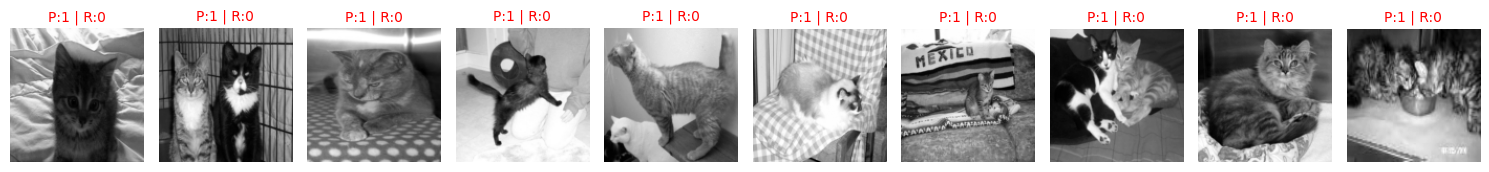

Train Epoch: 2 [0/17500 (0%)]	Loss: 0.692677


In [ ]:
use_cuda = torch.cuda.is_available()

torch.manual_seed(1111)

device = torch.device("cuda" if use_cuda else "cpu")

train_kwargs = {'batch_size': 2048}
test_kwargs = {'batch_size': 1024}
if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs, collate_fn=collate)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs, collate_fn=collate)

model = Net(net_input, net_output).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.999))

epochs = 8
scheduler = StepLR(optimizer, step_size=4, gamma=0.7)
best_acc = 0

for epoch in range(1, epochs + 1):
    train(10, False, model, device, train_loader, optimizer, epoch)
    acc, images_error = test(model, device, test_loader)
    plot_image_errors(images_error)
    # print(images_error)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "catsanddogs_cnn.pt")
    scheduler.step()